# 💰 SmartWealth AI — Complete Colab Demo

**BBA FinTech & AI Academic Project**

This notebook runs as a **standalone Google Colab project**. No GitHub cloning and no separate `.py` files are required. It demonstrates: **Risk Profiling → Goal Planning → SIP Calculation → Portfolio Allocation → Wealth Projection → Inflation Analysis → Explainable Insights**.

> ⚠️ Educational prototype only. The calculations use illustrative assumptions and are not financial advice, recommendations, guarantees, or market predictions.

In [1]:
# 0. Install / import dependencies
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("SmartWealth AI loaded successfully ✅")
print("Python / NumPy / Pandas / Matplotlib are ready.")

SmartWealth AI loaded successfully ✅
Python / NumPy / Pandas / Matplotlib are ready.


## 1. Core SmartWealth AI Engine

The following functions are embedded directly in this notebook so it can run independently in Colab.

In [2]:
# Risk profiling
RISK_BANDS = [
    (0, 34, "Conservative"),
    (35, 54, "Moderate"),
    (55, 79, "Moderate-Growth"),
    (80, 100, "Growth"),
]

RISK_DESCRIPTIONS = {
    "Conservative": "Focuses more on stability and relatively lower volatility.",
    "Moderate": "Balances growth potential with stability and diversification.",
    "Moderate-Growth": "Targets long-term growth while maintaining diversification.",
    "Growth": "Accepts higher volatility in this educational model for long-term growth potential.",
}

PORTFOLIO_PLANS = {
    "Conservative": {"Equity": .35, "Debt": .45, "Gold": .10, "Cash": .10},
    "Moderate": {"Equity": .50, "Debt": .35, "Gold": .10, "Cash": .05},
    "Moderate-Growth": {"Equity": .60, "Debt": .25, "Gold": .10, "Cash": .05},
    "Growth": {"Equity": .65, "Debt": .20, "Gold": .10, "Cash": .05},
}

def validate_score(score):
    if isinstance(score, bool):
        raise TypeError("Risk score must be numeric.")
    score = float(score)
    if not 0 <= score <= 100:
        raise ValueError("Risk score must be between 0 and 100.")
    return score

def risk_profile(score):
    score = validate_score(score)
    for low, high, label in RISK_BANDS:
        if low <= score <= high:
            return label
    raise ValueError("Could not classify risk score.")

def score_from_answers(answers):
    if not answers or any(int(a) not in range(1, 6) for a in answers):
        raise ValueError("Every questionnaire answer must be from 1 to 5.")
    avg = sum(answers) / len(answers)
    return round((avg - 1) / 4 * 100)

def risk_summary(score):
    score = validate_score(score)
    profile = risk_profile(score)
    return {"score": score, "profile": profile, "description": RISK_DESCRIPTIONS[profile]}

def allocation(profile, portfolio_value):
    if profile not in PORTFOLIO_PLANS:
        raise ValueError("Unknown risk profile.")
    if portfolio_value < 0:
        raise ValueError("Portfolio value cannot be negative.")
    return {k: v * portfolio_value for k, v in PORTFOLIO_PLANS[profile].items()}

In [3]:
# SIP and wealth calculations
def monthly_rate(annual_return):
    return annual_return / 12

def future_value_sip(monthly_sip, annual_return, years, due=True):
    if monthly_sip < 0 or years <= 0 or annual_return <= -1:
        raise ValueError("Invalid SIP, return, or time horizon.")
    r = monthly_rate(annual_return)
    n = int(years * 12)
    if abs(r) < 1e-12:
        return monthly_sip * n
    fv = monthly_sip * (((1 + r) ** n - 1) / r)
    return fv * (1 + r) if due else fv

def required_sip(target, annual_return, years):
    if target <= 0 or years <= 0 or annual_return <= -1:
        raise ValueError("Invalid target, return, or years.")
    r = monthly_rate(annual_return)
    n = int(years * 12)
    if abs(r) < 1e-12:
        return target / n
    return target * r / ((1 + r) ** n - 1)

def sip_breakdown(monthly_sip, annual_return, years):
    fv = future_value_sip(monthly_sip, annual_return, years)
    contribution = monthly_sip * years * 12
    return {
        "monthly_sip": monthly_sip,
        "total_contribution": contribution,
        "estimated_gain": fv - contribution,
        "future_value": fv,
    }

def yearly_projection(monthly_sip, annual_return, years):
    yrs = np.arange(1, years + 1)
    values = np.array([future_value_sip(monthly_sip, annual_return, int(y)) for y in yrs])
    contribution = monthly_sip * 12 * yrs
    return pd.DataFrame({"Year": yrs, "Contribution": contribution, "Projected Value": values, "Estimated Gain": values - contribution})

def inflation_adjusted(amount, inflation, years):
    if amount < 0 or inflation <= -1 or years < 0:
        raise ValueError("Invalid inflation inputs.")
    return amount / ((1 + inflation) ** years)

print("Calculation engine ready ✅")

Calculation engine ready ✅


## 2. Investor Risk Profile

Each answer is scored from **1 (low tolerance)** to **5 (high tolerance)**. The score is mapped transparently to a risk band.

In [4]:
# Example 10-question assessment
questions = [
    "How comfortable are you with temporary investment losses?",
    "How long can you stay invested?",
    "How would you react to a 15% market fall?",
    "How important is long-term growth to you?",
    "How stable is your income for investing?",
    "How comfortable are you with equity investments?",
    "Do you have an emergency fund?",
    "How much volatility can you tolerate?",
    "How comfortable are you with market uncertainty?",
    "Would you stay invested during a market downturn?",
]
answers = [4, 4, 3, 5, 4, 3, 4, 4, 5, 3]
risk_score = score_from_answers(answers)
summary = risk_summary(risk_score)

print(f"Risk Score   : {risk_score}/100")
print(f"Risk Profile : {summary['profile']}")
print(f"Explanation  : {summary['description']}")

Risk Score   : 72/100
Risk Profile : Moderate-Growth
Explanation  : Targets long-term growth while maintaining diversification.


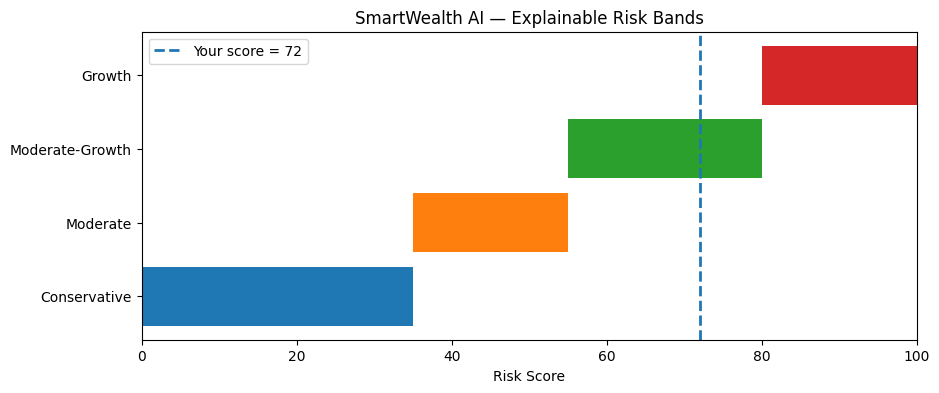

In [5]:
# Risk visualization
bands = pd.DataFrame({
    "Profile": [x[2] for x in RISK_BANDS],
    "Min": [x[0] for x in RISK_BANDS],
    "Max": [x[1] for x in RISK_BANDS],
})

plt.figure(figsize=(10, 4))
for _, row in bands.iterrows():
    plt.barh(row["Profile"], row["Max"] - row["Min"] + 1, left=row["Min"])
plt.axvline(risk_score, linestyle="--", linewidth=2, label=f"Your score = {risk_score}")
plt.xlim(0, 100)
plt.xlabel("Risk Score")
plt.title("SmartWealth AI — Explainable Risk Bands")
plt.legend()
plt.show()

## 3. Goal-Based SIP Calculator

The model estimates the monthly SIP needed to reach a future target under an assumed annual return.

In [6]:
# Goal inputs — change these values to experiment
target = 5_000_000       # ₹50 lakh
annual_return = 0.12     # 12% assumed annual return
years = 15

monthly_sip = required_sip(target, annual_return, years)
breakdown = sip_breakdown(monthly_sip, annual_return, years)

print(f"Target Amount        : ₹{target:,.0f}")
print(f"Assumed Return       : {annual_return*100:.1f}% p.a.")
print(f"Time Horizon         : {years} years")
print(f"Required Monthly SIP : ₹{monthly_sip:,.0f}")
print(f"Total Contribution   : ₹{breakdown['total_contribution']:,.0f}")
print(f"Estimated Gain       : ₹{breakdown['estimated_gain']:,.0f}")
print(f"Projected Future Value: ₹{breakdown['future_value']:,.0f}")

Target Amount        : ₹5,000,000
Assumed Return       : 12.0% p.a.
Time Horizon         : 15 years
Required Monthly SIP : ₹10,008
Total Contribution   : ₹1,801,513
Estimated Gain       : ₹3,248,487
Projected Future Value: ₹5,050,000


In [7]:
# Sensitivity: how the assumed return changes the required SIP
return_scenarios = [0.08, 0.10, 0.12, 0.15]
sip_comparison = pd.DataFrame({
    "Assumed Return": [f"{r*100:.0f}%" for r in return_scenarios],
    "Required Monthly SIP (₹)": [required_sip(target, r, years) for r in return_scenarios]
})
display(sip_comparison.style.format({"Required Monthly SIP (₹)": "₹{:,.0f}"}))

,Assumed Return,Required Monthly SIP (₹)
0,8%,"₹14,449"
1,10%,"₹12,064"
2,12%,"₹10,008"
3,15%,"₹7,479"


## 4. Illustrative Portfolio Allocation

The allocation below is a **project rule-set**, not personalized financial advice.

In [8]:
portfolio_value = 900_000  # ₹9 lakh example portfolio
profile = summary["profile"]
weights = PORTFOLIO_PLANS[profile]
amounts = allocation(profile, portfolio_value)

alloc_df = pd.DataFrame({
    "Asset Class": list(weights.keys()),
    "Allocation %": [v * 100 for v in weights.values()],
    "Amount (₹)": [amounts[k] for k in weights],
})
display(alloc_df.style.format({"Allocation %": "{:.0f}%", "Amount (₹)": "₹{:,.0f}"}))
print(f"Allocation total: {sum(weights.values())*100:.0f}%")

,Asset Class,Allocation %,Amount (₹)
0,Equity,60%,"₹540,000"
1,Debt,25%,"₹225,000"
2,Gold,10%,"₹90,000"
3,Cash,5%,"₹45,000"


Allocation total: 100%


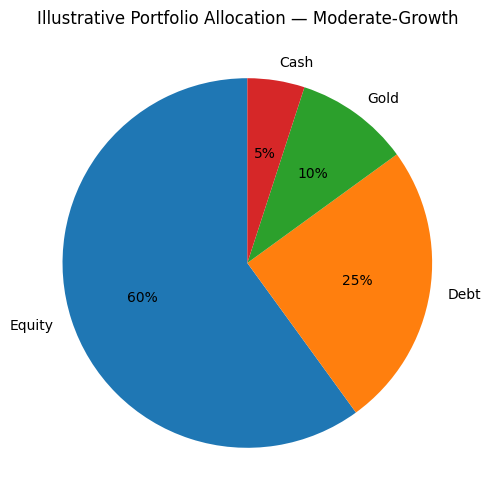

In [9]:
plt.figure(figsize=(7, 6))
plt.pie(list(weights.values()), labels=list(weights.keys()), autopct="%1.0f%%", startangle=90)
plt.title(f"Illustrative Portfolio Allocation — {profile}")
plt.show()

## 5. Wealth Projection — Conservative / Expected / Optimistic

These are mathematical scenarios based on assumed returns, **not forecasts**.

In [10]:
scenarios = {"Conservative": 0.08, "Expected": 0.12, "Optimistic": 0.15}
projection_tables = {}
rows = []

for name, rate in scenarios.items():
    table = yearly_projection(monthly_sip, rate, years)
    projection_tables[name] = table
    rows.append({
        "Scenario": name,
        "Assumed Return": f"{rate*100:.0f}%",
        "Future Value (₹)": table["Projected Value"].iloc[-1],
        "Total Contribution (₹)": table["Contribution"].iloc[-1],
        "Estimated Gain (₹)": table["Estimated Gain"].iloc[-1],
    })

scenario_summary = pd.DataFrame(rows)
display(scenario_summary.style.format({
    "Future Value (₹)": "₹{:,.0f}",
    "Total Contribution (₹)": "₹{:,.0f}",
    "Estimated Gain (₹)": "₹{:,.0f}"
}))

,Scenario,Assumed Return,Future Value (₹),Total Contribution (₹),Estimated Gain (₹)
0,Conservative,8%,"₹3,486,379","₹1,801,513","₹1,684,866"
1,Expected,12%,"₹5,050,000","₹1,801,513","₹3,248,487"
2,Optimistic,15%,"₹6,774,319","₹1,801,513","₹4,972,806"


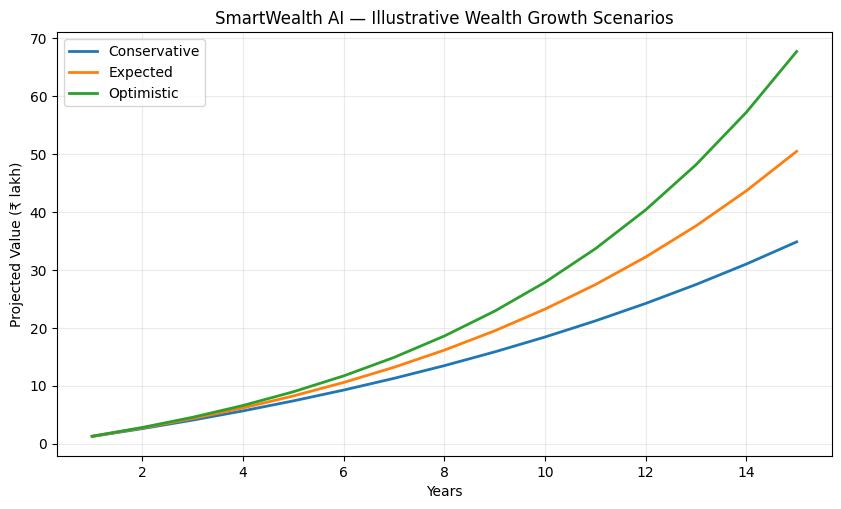

In [11]:
plt.figure(figsize=(10, 5.5))
for name, table in projection_tables.items():
    plt.plot(table["Year"], table["Projected Value"] / 100_000, linewidth=2, label=name)
plt.xlabel("Years")
plt.ylabel("Projected Value (₹ lakh)")
plt.title("SmartWealth AI — Illustrative Wealth Growth Scenarios")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

## 6. Goal Progress + Inflation Awareness

In [12]:
current_value = 2_100_000  # ₹21 lakh already accumulated
inflation = 0.06            # 6% illustrative annual inflation

progress = min(current_value / target * 100, 100)
remaining = max(target - current_value, 0)
today_value = inflation_adjusted(target, inflation, years)

print(f"Goal Progress          : {progress:.1f}%")
print(f"Current Value          : ₹{current_value:,.0f}")
print(f"Remaining Goal Amount  : ₹{remaining:,.0f}")
print(f"Inflation Assumption   : {inflation*100:.1f}% p.a.")
print(f"Future ₹{target:,.0f} in today's purchasing power: ₹{today_value:,.0f}")

Goal Progress          : 42.0%
Current Value          : ₹2,100,000
Remaining Goal Amount  : ₹2,900,000
Inflation Assumption   : 6.0% p.a.
Future ₹5,000,000 in today's purchasing power: ₹2,086,325


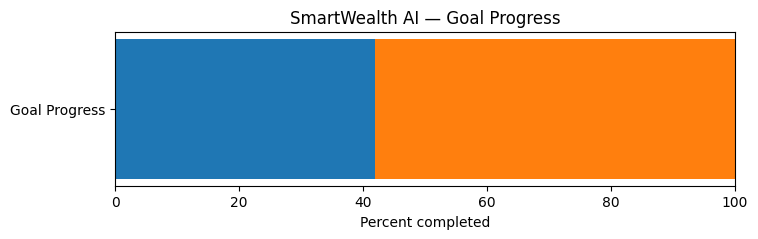

In [13]:
plt.figure(figsize=(8, 2))
plt.barh(["Goal Progress"], [progress])
plt.barh(["Goal Progress"], [100-progress], left=[progress])
plt.xlim(0, 100)
plt.xlabel("Percent completed")
plt.title("SmartWealth AI — Goal Progress")
plt.show()

## 7. Explainable AI-Style Insight Layer

This is intentionally **deterministic and explainable**. It is not a trained machine-learning model.

In [14]:
def generate_insights(profile, score, weights, monthly_sip, years, target, current_value):
    insights = []
    equity = weights["Equity"] * 100
    progress = min(current_value / target * 100, 100)
    insights.append(f"Risk score {score}/100 maps to the {profile} project profile.")
    insights.append(f"The illustrative allocation uses {equity:.0f}% equity and diversifies the remainder across debt, gold and cash.")
    insights.append(f"The model estimates a monthly SIP of about ₹{monthly_sip:,.0f} for the selected target and assumptions.")
    insights.append(f"The current goal progress is approximately {progress:.1f}%.")
    insights.append("Changing the assumed return or time horizon can materially change the calculated SIP and projected value.")
    return insights

print("SMARTWEALTH AI — KEY INSIGHTS")
print("-" * 55)
for i, insight in enumerate(generate_insights(profile, risk_score, weights, monthly_sip, years, target, current_value), 1):
    print(f"{i}. {insight}")

SMARTWEALTH AI — KEY INSIGHTS
-------------------------------------------------------
1. Risk score 72/100 maps to the Moderate-Growth project profile.
2. The illustrative allocation uses 60% equity and diversifies the remainder across debt, gold and cash.
3. The model estimates a monthly SIP of about ₹10,008 for the selected target and assumptions.
4. The current goal progress is approximately 42.0%.
5. Changing the assumed return or time horizon can materially change the calculated SIP and projected value.


## 8. Automated Sanity Checks

These checks make the academic prototype easier to demonstrate in a viva.

In [15]:
# Basic tests
assert risk_profile(0) == "Conservative"
assert risk_profile(54) == "Moderate"
assert risk_profile(72) == "Moderate-Growth"
assert risk_profile(100) == "Growth"
assert abs(sum(PORTFOLIO_PLANS[profile].values()) - 1) < 1e-9
assert monthly_sip > 0
assert breakdown["future_value"] >= breakdown["total_contribution"]
assert abs(progress - current_value / target * 100) < 1e-9

print("7/7 sanity checks passed successfully ✅")

7/7 sanity checks passed successfully ✅


## 9. Final Project Flow

**Risk Profile → Financial Goal → Required SIP → Portfolio Allocation → Scenario Projection → Inflation Check → Explainable Insights**

### Viva points
- The risk engine is a transparent rules-based model.
- SIP calculations use monthly compounding assumptions.
- Portfolio allocation is illustrative and profile-driven.
- Scenario analysis shows sensitivity to different assumed returns.
- Inflation analysis demonstrates the difference between nominal value and purchasing power.
- A production financial product would require validated suitability rules, quality-controlled data, security, compliance, testing, and human oversight.